# Code-capacity logical error rates

The code-capacity model asks a clean question: if each physical bit or qubit is corrupted independently, how often does a chosen decoder leave a logical error after correction?
There are no faulty measurements or gates in this model.
The result depends on both the code and the decoder.

qLDPC estimates the decoder's success rate separately at each sampled error weight, then reuses those samples to evaluate many physical error rates.
That makes a sweep inexpensive after the initial sampling step.


## Setup

Run the next cell once in a fresh notebook environment.
IPython's `%pip` magic installs into the active kernel, so the following imports use the same environment.


In [1]:
%%capture
%pip install qldpc matplotlib

In [2]:
from collections.abc import Sequence
from itertools import cycle

import matplotlib.pyplot as plt
import numpy as np
from sympy.abc import x, y

from qldpc import codes

## One reusable workflow

`get_logical_error_rate_func` returns an estimator and a statistical standard deviation.
Errors heavier than the sample budget reaches are conservatively counted as failures.
The estimator's `truncation_error_bound` reports how much that choice can raise the result, so the shaded band is asymmetric.

The band is a guide to statistical and truncation uncertainty, not an exact confidence interval.


In [3]:
def code_label(code):
    known_distance = code.get_distance_if_known()
    brackets = ("[", "]") if isinstance(code, codes.ClassicalCode) else ("[[", "]]")
    entries = [len(code), code.dimension]
    if known_distance is not None:
        entries.append(known_distance)
    return brackets[0] + ", ".join(map(str, entries)) + brackets[1]


def make_code_capacity_figure(
    codes_to_plot: Sequence[codes.ClassicalCode | codes.QuditCode],
    *,
    error_rates: Sequence[float] = tuple(np.logspace(-2, -0.1, 60)),
    num_samples: int = 10_000,
    figsize: tuple[float, float] = (5.5, 4.2),
    **decoder_kwargs,
):
    figure, axis = plt.subplots(figsize=figsize)
    styles = cycle(("o-", "s--", "^-.", "D:"))

    for code_to_plot, style in zip(codes_to_plot, styles):
        estimator = code_to_plot.get_logical_error_rate_func(
            num_samples=num_samples,
            max_error_rate=max(error_rates),
            **decoder_kwargs,
        )
        logical_rates, statistical_error = estimator(error_rates)
        truncation = estimator.truncation_error_bound(error_rates)

        line, *_ = axis.plot(
            error_rates,
            logical_rates,
            style,
            markevery=8,
            label=code_label(code_to_plot),
        )
        axis.fill_between(
            error_rates,
            np.maximum(logical_rates - statistical_error - truncation, 0),
            logical_rates + statistical_error,
            color=line.get_color(),
            alpha=0.18,
        )

    reference_rates = [min(error_rates), max(error_rates)]
    axis.plot(
        reference_rates,
        reference_rates,
        color="black",
        linestyle=":",
        label=r"$p_{\mathrm{logical}}=p_{\mathrm{physical}}$",
    )
    axis.loglog()
    axis.set_xlim(right=1)
    axis.set_ylim(bottom=max(min(error_rates) ** 2, axis.get_ylim()[0]), top=1)
    axis.set_xlabel("physical error rate")
    axis.set_ylabel("estimated logical error rate")
    axis.legend(loc="best")
    axis.grid(which="both", alpha=0.3)
    figure.tight_layout()
    return figure, axis

## Repetition codes

Minimum-weight perfect matching (MWPM) is exact for the one-dimensional matching problem behind these repetition codes.
At low physical error rates, increasing the odd code distance should suppress logical failures.
The finite sample budget eventually limits how far down the plot that trend can be resolved.


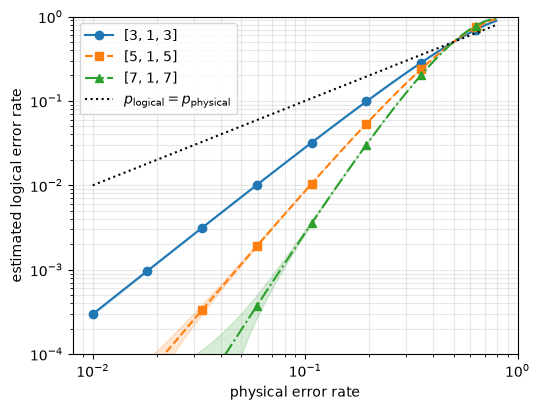

In [4]:
repetition_codes = [codes.RepetitionCode(distance) for distance in (3, 5, 7)]
make_code_capacity_figure(repetition_codes, with_MWPM=True)
plt.show()

The curves separate over the sampled range, but the shaded regions widen where few relevant failures were observed.
Do not read a threshold or asymptotic scaling law from three small codes.


## Surface codes

The same workflow accepts quantum CSS codes.
With no Pauli bias supplied, each erroneous qubit receives X, Y, or Z with equal probability.


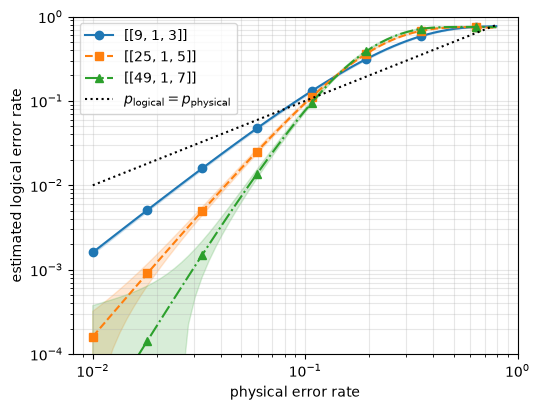

In [5]:
surface_codes = [codes.SurfaceCode(distance) for distance in (3, 5, 7)]
make_code_capacity_figure(surface_codes, with_MWPM=True)
plt.show()

## Bivariate bicycle codes

For this small comparison, BP+LSD replaces MWPM because the bivariate-bicycle checks do not produce a simple matching graph.
The code labels omit distance when qLDPC does not already know an exact value; plotting a randomized upper bound as though it were exact would be misleading.


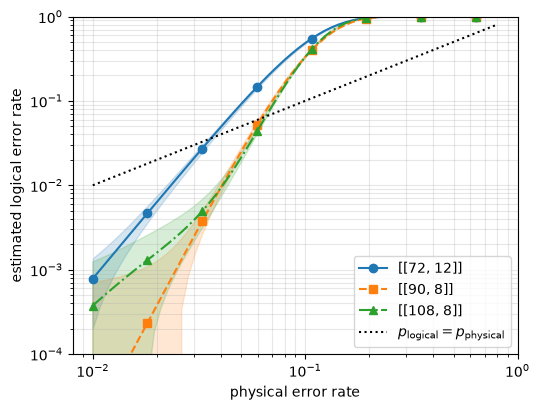

In [6]:
bb_codes = [
    codes.BBCode({x: 6, y: 6}, x**3 + y + y**2, y**3 + x + x**2),
    codes.BBCode({x: 15, y: 3}, x**9 + y + y**2, 1 + x**2 + x**7),
    codes.BBCode({x: 9, y: 6}, x**3 + y + y**2, y**3 + x + x**2),
]
make_code_capacity_figure(bb_codes, with_BP_LSD=True)
plt.show()

These estimates compare the configured decoder on small sample budgets.
They are useful for checking a workflow or forming a hypothesis, not for claiming a threshold.
